In [1]:
import sys
sys.path.append("/Users/emilieyu/endotehelial-masboss")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import copy

from abm.rho_lookup_table import RhoLookupTable
from abm.endothelial_cell import EndothelialCell
from abm.stress_fibre import StressFibre
from abm.flow_field import FlowField
from src.config import load_abm_sim_cfg, load_bm_sweep_cfg
from src.paths import BM_RESULTS_DIR

from abm.scripts.run_abm_sim import run_abm_sim, run_abm_sim_single, get_perb_cfg, plot_cell

sim_cfg = load_abm_sim_cfg()
lut = RhoLookupTable(sim_cfg, BM_RESULTS_DIR)
perbs = sim_cfg['perturbations']


>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.395 RhoC=0.406


In [2]:
dsp_cfg = get_perb_cfg(sim_cfg, perbs['DSP_KO'])
tjp1_cfg = get_perb_cfg(sim_cfg, perbs['TJP1_KO'])
jcad_cfg = get_perb_cfg(sim_cfg, perbs['JCAD_KO'])
tjp1_jcad_cfg = get_perb_cfg(sim_cfg, perbs['TJP1_JCAD_DKO'])
dsp_jcad_cfg = get_perb_cfg(sim_cfg, perbs['DSP_JCAD_DKO'])

>>> INFO: Initiated flow field with magnitude 10.0 and unit direction [1. 0.]
{'length': 41.65128760072449, 'rest_length': 26.29068276024797, 'tension': 13.85485330874164, 'activation': 0.8314206073280153}


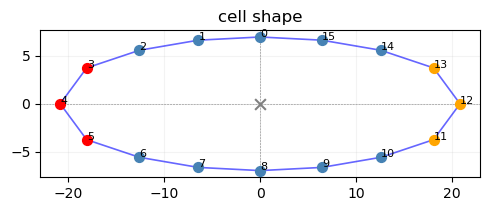

In [3]:
res_wt = run_abm_sim_single(sim_cfg, lut, 2000, 'WT', True)

In [5]:
res_wt['cell_final'], res_wt['springs_final']

({'cell_id': 0,
  'ar': np.float64(2.562),
  'orientation': np.float64(0.0),
  'area_ratio': np.float64(1.0134),
  'mean_rhoa_pole': 0.56,
  'mean_rhoa_lat': 0.475,
  'mean_rhoa': 0.507,
  'mean_rhoc': 0.563,
  'a_sf': 0.831,
  'sf_tension': np.float64(13.855),
  'k_pole': np.float64(2.076),
  'k_flank': np.float64(1.951),
  'tensile_pole': 27.148,
  'f_total': 10.0},
     id   side  extension  stiffness  tension  alignment  activation
 0    0  flank     1.3416     1.9524   4.0620      0.999       0.855
 1    1  flank     1.3483     1.9496   4.0042      0.986       0.855
 2    2  polar     1.2377     2.0305   3.9232      0.948       0.847
 3    3  polar     0.3513     2.1219   2.2240      0.592       0.838
 4    4  polar     0.3513     2.1219   2.2240      0.592       0.838
 5    5  polar     1.2377     2.0305   3.9232      0.948       0.847
 6    6  flank     1.3483     1.9496   4.0042      0.986       0.855
 7    7  flank     1.3416     1.9524   4.0620      0.999       0.855
 8    8 

>>> INFO: Initiated flow field with magnitude 10.0 and unit direction [1. 0.]
{'length': 42.495778958294096, 'rest_length': 26.29068276024797, 'tension': 14.033100570098213, 'activation': 0.8538567409231338}


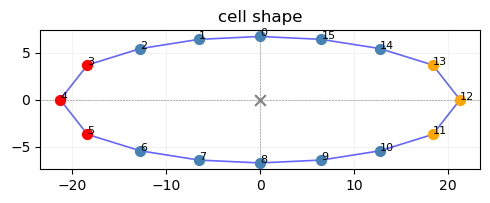

In [6]:
res_jcad = run_abm_sim_single(jcad_cfg, lut, 3000, 'JCAD', True)

In [7]:
res_jcad['cell_final'], res_jcad['springs_final']

({'cell_id': 0,
  'ar': np.float64(2.679),
  'orientation': np.float64(0.0),
  'area_ratio': np.float64(1.0067),
  'mean_rhoa_pole': 0.491,
  'mean_rhoa_lat': 0.433,
  'mean_rhoa': 0.455,
  'mean_rhoc': 0.488,
  'a_sf': 0.854,
  'sf_tension': np.float64(14.033),
  'k_pole': np.float64(1.952),
  'k_flank': np.float64(1.867),
  'tensile_pole': 26.824,
  'f_total': 10.0},
     id   side  extension  stiffness  tension  alignment  activation
 0    0  flank     1.4252     1.8685   3.9681      0.999       0.863
 1    1  flank     1.4260     1.8663   3.9080      0.988       0.863
 2    2  polar     1.3264     1.9212   3.7942      0.955       0.858
 3    3  polar     0.3535     1.9830   1.9705      0.618       0.851
 4    4  polar     0.3535     1.9830   1.9705      0.618       0.851
 5    5  polar     1.3264     1.9212   3.7942      0.955       0.858
 6    6  flank     1.4260     1.8663   3.9080      0.988       0.863
 7    7  flank     1.4252     1.8685   3.9681      0.999       0.863
 8    8

>>> INFO: Initiated flow field with magnitude 10.0 and unit direction [1. 0.]
{'length': 48.436229982627296, 'rest_length': 26.29068276024797, 'tension': 19.31466420943405, 'activation': 0.7928219200338495}


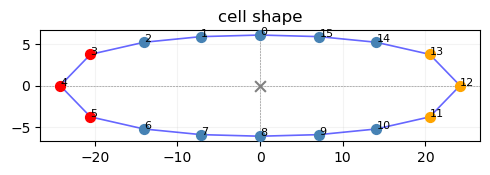

In [8]:
res_dsp = run_abm_sim_single(dsp_cfg, lut, 2000, 'DSP', True)

In [9]:
res_dsp['cell_final'], res_dsp['springs_final']

({'cell_id': 0,
  'ar': np.float64(3.171),
  'orientation': np.float64(0.0),
  'area_ratio': np.float64(1.0687),
  'mean_rhoa_pole': 0.247,
  'mean_rhoa_lat': 0.247,
  'mean_rhoa': 0.247,
  'mean_rhoc': 0.691,
  'a_sf': 0.793,
  'sf_tension': np.float64(19.315),
  'k_pole': np.float64(1.495),
  'k_flank': np.float64(1.495),
  'tensile_pole': 31.052,
  'f_total': 10.0},
     id   side  extension  stiffness  tension  alignment  activation
 0    0  flank     2.0534     1.4946   3.8264      1.000       0.901
 1    1  flank     2.0551     1.4946   3.7966      0.995       0.901
 2    2  polar     2.0860     1.4946   3.7943      0.975       0.901
 3    3  polar     0.9921     1.4946   2.1229      0.696       0.901
 4    4  polar     0.9921     1.4946   2.1229      0.696       0.901
 5    5  polar     2.0860     1.4946   3.7943      0.975       0.901
 6    6  flank     2.0551     1.4946   3.7966      0.995       0.901
 7    7  flank     2.0534     1.4946   3.8264      1.000       0.901
 8    8

>>> INFO: Initiated flow field with magnitude 10.0 and unit direction [1. 0.]
{'length': 46.217166548006404, 'rest_length': 26.29068276024797, 'tension': 17.118457421820757, 'activation': 0.8277536375648216}


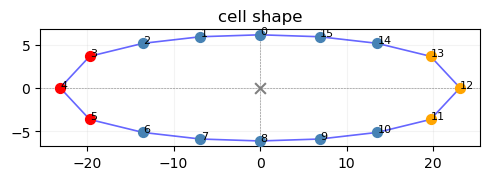

In [10]:
res_dsp_jcad = run_abm_sim_single(dsp_jcad_cfg, lut, 2000, 'DSP_JCAD', True)

In [11]:
res_dsp_jcad['cell_final'], res_dsp_jcad['springs_final']

({'cell_id': 0,
  'ar': np.float64(3.077),
  'orientation': np.float64(0.0),
  'area_ratio': np.float64(1.011),
  'mean_rhoa_pole': 0.309,
  'mean_rhoa_lat': 0.309,
  'mean_rhoa': 0.309,
  'mean_rhoc': 0.575,
  'a_sf': 0.828,
  'sf_tension': np.float64(17.118),
  'k_pole': np.float64(1.618),
  'k_flank': np.float64(1.618),
  'tensile_pole': 29.02,
  'f_total': 10.0},
     id   side  extension  stiffness  tension  alignment  activation
 0    0  flank     1.8029     1.6176   3.8376      0.999       0.888
 1    1  flank     1.7972     1.6176   3.7890      0.993       0.888
 2    2  polar     1.7902     1.6176   3.7188      0.971       0.888
 3    3  polar     0.6979     1.6176   1.9075      0.681       0.888
 4    4  polar     0.6979     1.6176   1.9075      0.681       0.888
 5    5  polar     1.7902     1.6176   3.7188      0.971       0.888
 6    6  flank     1.7972     1.6176   3.7890      0.993       0.888
 7    7  flank     1.8029     1.6176   3.8376      0.999       0.888
 8    8  

>>> INFO: Initiated flow field with magnitude 10.0 and unit direction [1. 0.]
{'length': 38.57266643565953, 'rest_length': 26.29068276024797, 'tension': 9.997662640049263, 'activation': 0.9239124910209213}


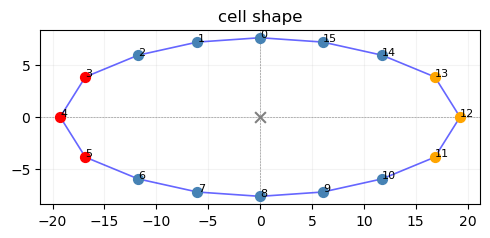

In [12]:
res_tjp1 = run_abm_sim_single(tjp1_cfg, lut, 3000, 'TJP1', True)

In [13]:
res_tjp1['cell_final'], res_tjp1['springs_final']

({'cell_id': 0,
  'ar': np.float64(2.21),
  'orientation': np.float64(0.0),
  'area_ratio': np.float64(1.018),
  'mean_rhoa_pole': 0.701,
  'mean_rhoa_lat': 0.641,
  'mean_rhoa': 0.663,
  'mean_rhoc': 0.254,
  'a_sf': 0.924,
  'sf_tension': np.float64(9.998),
  'k_pole': np.float64(2.371),
  'k_flank': np.float64(2.282),
  'tensile_pole': 24.709,
  'f_total': 10.0},
     id   side  extension  stiffness  tension  alignment  activation
 0    0  flank     0.9570     2.2832   4.2570      0.998       0.822
 1    1  flank     0.9791     2.2815   4.2120      0.976       0.822
 2    2  polar     0.9502     2.3398   4.1771      0.924       0.816
 3    3  polar     0.2762     2.4022   2.6273      0.531       0.810
 4    4  polar     0.2762     2.4022   2.6273      0.531       0.810
 5    5  polar     0.9502     2.3398   4.1771      0.924       0.816
 6    6  flank     0.9791     2.2815   4.2120      0.976       0.822
 7    7  flank     0.9570     2.2832   4.2570      0.998       0.822
 8    8  f

>>> INFO: Initiated flow field with magnitude 10.0 and unit direction [1. 0.]
{'length': 40.43911046888268, 'rest_length': 26.29068276024797, 'tension': 11.6671483451588, 'activation': 0.9041884953731346}


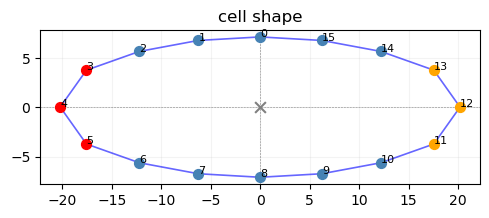

In [14]:
res_tjp1_jcad = run_abm_sim_single(tjp1_jcad_cfg, lut, 2000, 'TJP1_JCAD', True)

In [ ]:
res_tjp1_jcad['cell_final'], res_tjp1_jcad['springs_final']

In [15]:
ts_df, ss_df, diag_ts_df, diag_ss_df = run_abm_sim(sim_cfg, lut, 6000)

>>> INFO: Running abm simulation perturbation: WT (6000 steps).
>>> INFO: Initiated flow field with magnitude 10.0 and unit direction [1. 0.]
{'length': 41.61774117628201, 'rest_length': 26.29068276024797, 'tension': 13.835008829802739, 'activation': 0.8312237007023688}
WT                  2.558    180.0°  0.831 
>>> INFO: Running abm simulation perturbation: DSP_KO (6000 steps).
>>> INFO: Initiated flow field with magnitude 10.0 and unit direction [1. 0.]
{'length': 47.98152431674848, 'rest_length': 26.29068276024797, 'tension': 19.001190911269376, 'activation': 0.7925608498668387}
DSP_KO              3.346      0.0°  0.793 
>>> INFO: Running abm simulation perturbation: TJP1_KO (6000 steps).
>>> INFO: Initiated flow field with magnitude 10.0 and unit direction [1. 0.]
{'length': 38.279737517479376, 'rest_length': 26.29068276024797, 'tension': 9.792369108161294, 'activation': 0.9239248209904277}
TJP1_KO             2.173      0.0°  0.924 
>>> INFO: Running abm simulation perturbation:

In [ ]:
ss_df

In [ ]:
diag_ss_df